#### In here we will clean the data and explain our intentions as well as make visuals for a better understanding

In [10]:
#Import all libraries here 
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


For the claims_test and claims_train we are going to create a new column for analysis of teh frequency of claims 

In [11]:
# Load your dataset
df = pd.read_csv("Data/claims_test.csv")

# --- Step 1: Filter Exposure (as you did) ---
df = df[df['Exposure'] <= 1].copy()

# --- Step 2: Create Target Variable (as you did) ---
df['ClaimFrequency'] = np.where(df['Exposure'] > 0, df['ClaimNb'] / df['Exposure'], 0)

# --- Step 3 (New): Handle Outliers by Clipping ---
# Set reasonable upper bounds for age and bonus/malus score
df['DrivAge'] = df['DrivAge'].clip(18, 90)
df['BonusMalus'] = df['BonusMalus'].clip(upper=200) 

# --- Step 4 (New): Coalesce Rare Categories ---
# For VehBrand, find brands with less than 1% of occurrences and group them
brand_counts = df['VehBrand'].value_counts(normalize=True)
rare_brands = brand_counts[brand_counts < 0.01].index
df['VehBrand'] = df['VehBrand'].replace(rare_brands, 'Other')

# --- Step 5 (New): Drop Unnecessary Columns ---
# IDPol is an identifier and ClaimNb was used to create the target
df = df.drop(columns=['IDpol'])

# Save the result as a new CSV
df.to_csv("Data/claims_test_with_freq_filtered.csv", index=False)

In [12]:


# Load your dataset
df = pd.read_csv("Data/claims_train.csv")

# --- Step 1: Filter Exposure (as you did) ---
df = df[df['Exposure'] <= 1].copy()

# --- Step 2: Create Target Variable (as you did) ---
df['ClaimFrequency'] = np.where(df['Exposure'] > 0, df['ClaimNb'] / df['Exposure'], 0)

# --- Step 3 (New): Handle Outliers by Clipping ---
# Set reasonable upper bounds for age and bonus/malus score
df['DrivAge'] = df['DrivAge'].clip(18, 90)
df['BonusMalus'] = df['BonusMalus'].clip(upper=200) # Example upper limit

# --- Step 4 (New): Coalesce Rare Categories ---
# For VehBrand, find brands with less than 1% of occurrences and group them
brand_counts = df['VehBrand'].value_counts(normalize=True)
rare_brands = brand_counts[brand_counts < 0.01].index
df['VehBrand'] = df['VehBrand'].replace(rare_brands, 'Other')

# --- Step 5 (New): Drop Unnecessary Columns ---
# IDPol is an identifier and ClaimNb was used to create the target
df = df.drop(columns=['IDpol'])
df.to_csv("Data/claims_train_with_freq_filtered.csv", index=False)

Visualitation on 

Training set size: 541416
Test set size: 135373
Combined dataset size: 676789
After removing top 1% outliers: 670394 records


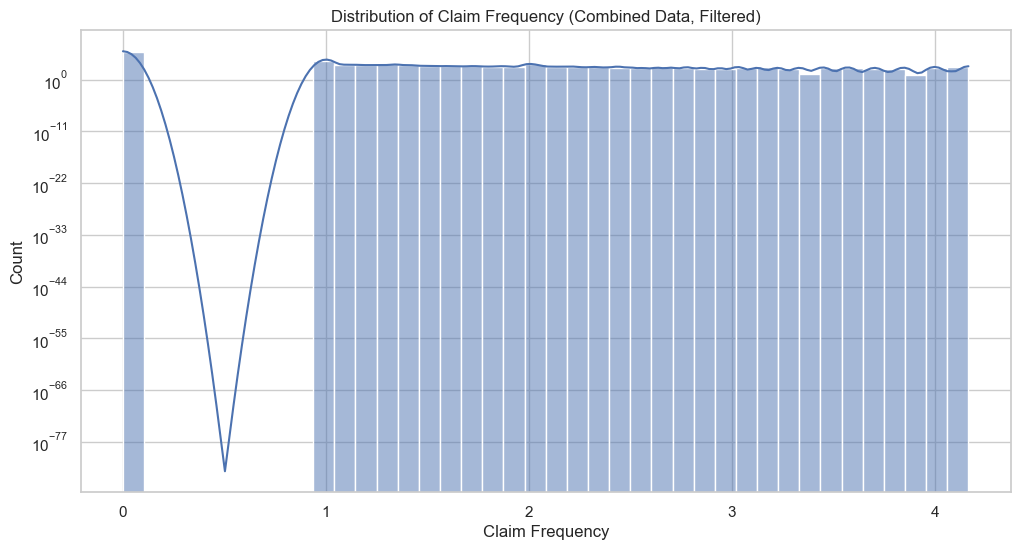

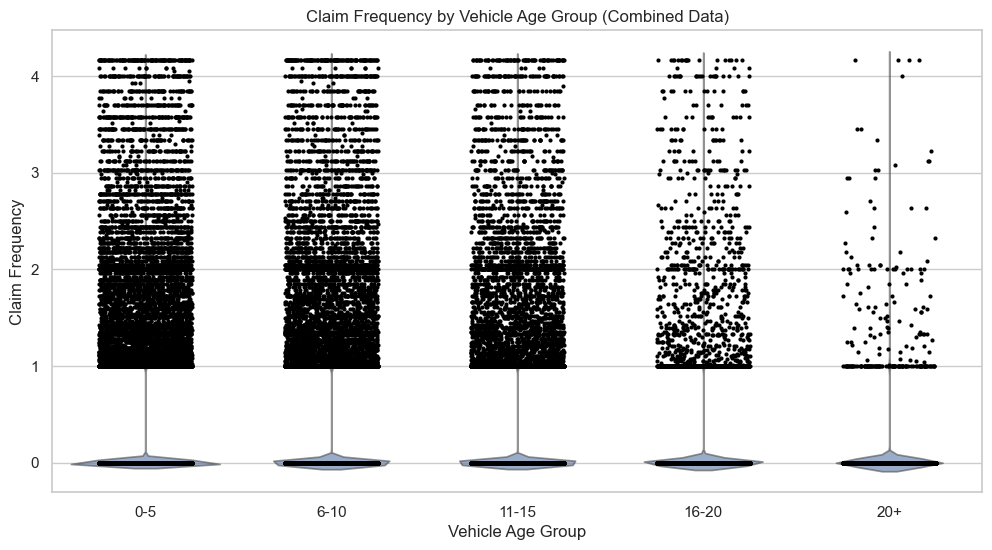

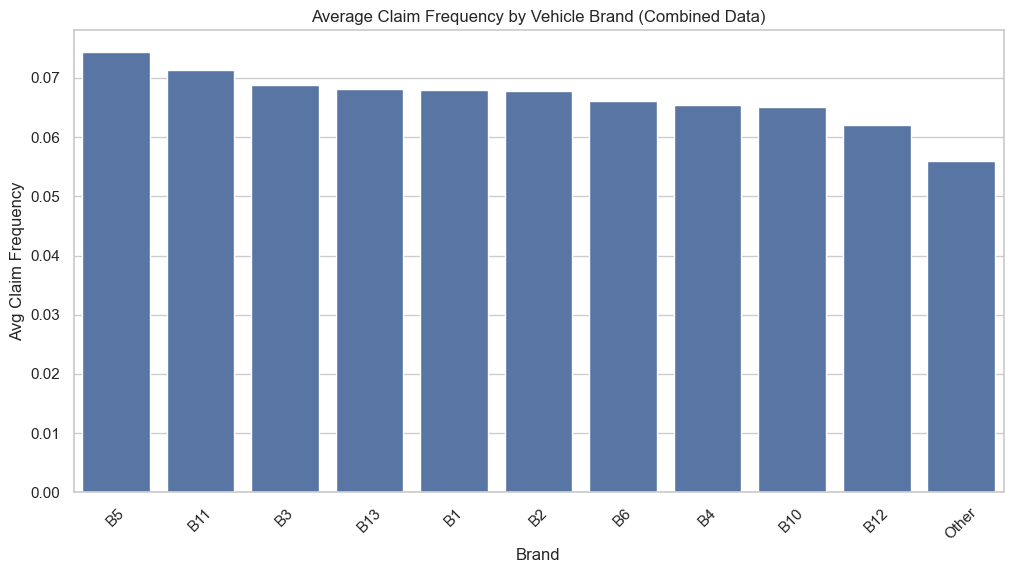

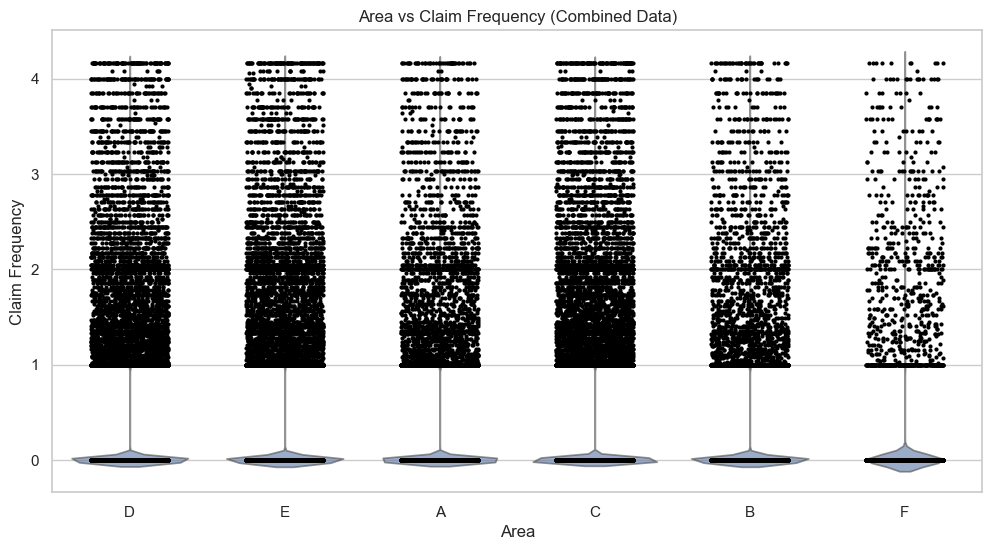


Basic statistics for combined dataset:
Mean Claim Frequency: 0.2644
Median Claim Frequency: 0.0000
Std Claim Frequency: 4.5981
Max Claim Frequency: 732.0000


In [13]:


# Load both datasets with frequency information
df_train = pd.read_csv('Data/claims_train_with_freq_filtered.csv')
df_test = pd.read_csv('Data/claims_test_with_freq_filtered.csv')

# Merge the datasets for overall analysis
df_combined = pd.concat([df_train, df_test], ignore_index=True)

print(f"Training set size: {len(df_train)}")
print(f"Test set size: {len(df_test)}")
print(f"Combined dataset size: {len(df_combined)}")

# Remove top 1% outliers from combined data
cap_value = df_combined['ClaimFrequency'].quantile(0.99)
df_viz = df_combined[df_combined['ClaimFrequency'] <= cap_value].copy()

print(f"After removing top 1% outliers: {len(df_viz)} records")

# Bin Vehicle Age for better visualization
df_viz['VehAgeGroup'] = pd.cut(df_viz['VehAge'],
                               bins=[0, 5, 10, 15, 20, 50],
                               labels=['0-5', '6-10', '11-15', '16-20', '20+'])

sns.set_theme(style="whitegrid")

# 1️⃣ Distribution – with KDE + log scale
plt.figure(figsize=(12,6))
sns.histplot(df_viz['ClaimFrequency'], bins=40, kde=True)
plt.title("Distribution of Claim Frequency (Combined Data, Filtered)")
plt.xlabel("Claim Frequency")
plt.yscale('log')
plt.show()

# 2️⃣ Vehicle Age vs Claim Frequency – Violin + Strip
plt.figure(figsize=(12,6))
sns.violinplot(data=df_viz, x='VehAgeGroup', y='ClaimFrequency', inner=None, alpha=0.6)
sns.stripplot(data=df_viz, x='VehAgeGroup', y='ClaimFrequency', color='black', size=3, jitter=0.25)
plt.title("Claim Frequency by Vehicle Age Group (Combined Data)")
plt.xlabel("Vehicle Age Group")
plt.ylabel("Claim Frequency")
plt.show()

# 3️⃣ Brand – Sorted + highlight top performers
plt.figure(figsize=(12,6))
brand_means = df_viz.groupby('VehBrand')['ClaimFrequency'].mean().sort_values(ascending=False)
sns.barplot(x=brand_means.index, y=brand_means.values)
plt.title("Average Claim Frequency by Vehicle Brand (Combined Data)")
plt.xlabel("Brand")
plt.ylabel("Avg Claim Frequency")
plt.xticks(rotation=45)
plt.show()

# 4️⃣ Area vs Claim Frequency – Violin + Strip
plt.figure(figsize=(12,6))
sns.violinplot(data=df_viz, x='Area', y='ClaimFrequency', inner=None, alpha=0.6)
sns.stripplot(data=df_viz, x='Area', y='ClaimFrequency', color='black', size=3, jitter=0.25)
plt.title("Area vs Claim Frequency (Combined Data)")
plt.xlabel("Area")
plt.ylabel("Claim Frequency")
plt.show()

# Optional: Show basic statistics
print("\nBasic statistics for combined dataset:")
print(f"Mean Claim Frequency: {df_combined['ClaimFrequency'].mean():.4f}")
print(f"Median Claim Frequency: {df_combined['ClaimFrequency'].median():.4f}")
print(f"Std Claim Frequency: {df_combined['ClaimFrequency'].std():.4f}")
print(f"Max Claim Frequency: {df_combined['ClaimFrequency'].max():.4f}")

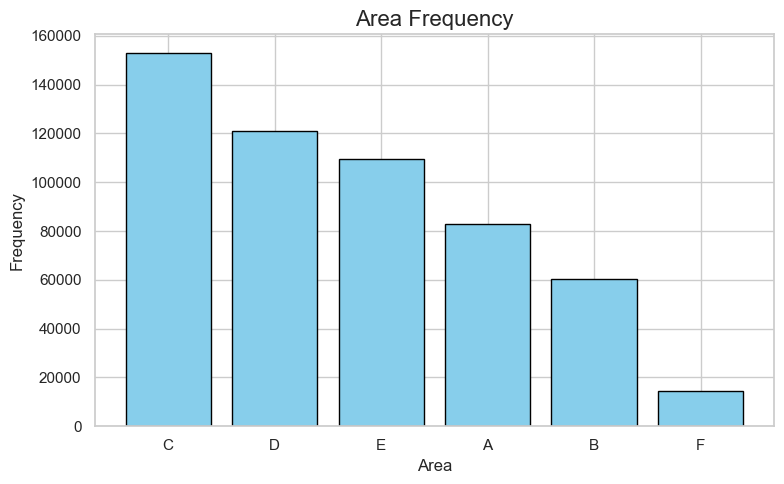

Area
C    152993
D    121001
E    109630
A     83062
B     60341
F     14389
Name: count, dtype: int64


In [14]:
#Area frequency
Area = df["Area"].value_counts()
x = Area.index
y = Area.values

plt.figure(figsize=(8, 5))
plt.bar(x,y,color='skyblue', edgecolor='black')
plt.title('Area Frequency', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()
print(Area)

In [15]:
#Data with 0 claims
Claimed = df[df["ClaimNb"]> 0]
Claimed

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimFrequency
36,1,0.78,E,4,3,50,50,B12,Regular,4128,R52,1.282051
64,2,1.00,D,7,1,50,50,B3,Regular,511,R24,2.000000
84,1,0.06,E,4,0,52,55,B12,Regular,5433,R93,16.666667
88,1,0.08,D,6,2,49,95,B3,Diesel,824,R91,12.500000
97,1,1.00,A,6,6,44,62,B13,Diesel,10,R24,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
542324,1,0.66,A,7,9,26,100,B2,Regular,26,R82,1.515152
542363,1,1.00,B,10,9,89,50,B1,Regular,91,R24,1.000000
542364,1,0.09,D,7,4,37,82,B12,Regular,1326,R93,11.111111
542371,1,0.24,F,9,0,69,50,B12,Regular,27000,R11,4.166667


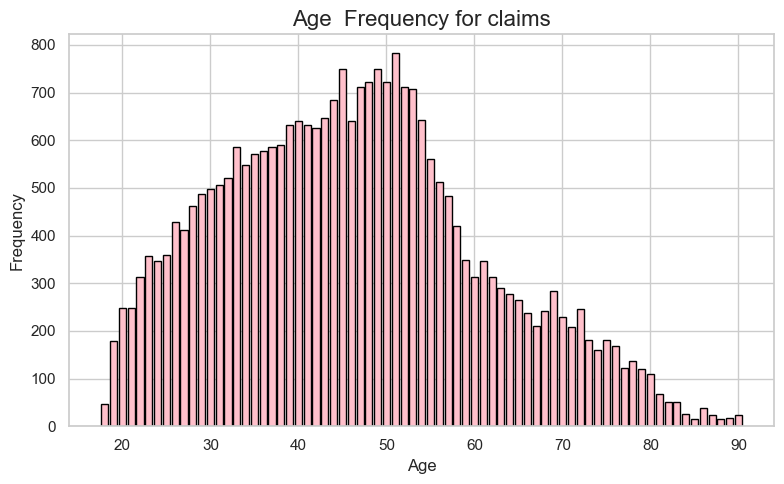

In [16]:
# Ages with claims over 0 
Age = Claimed["DrivAge"].value_counts()
x2 = Age.index
y2 = Age.values
plt.figure(figsize=(8, 5))
plt.bar(x2,y2,color='pink', edgecolor='black')
plt.title('Age  Frequency for claims', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


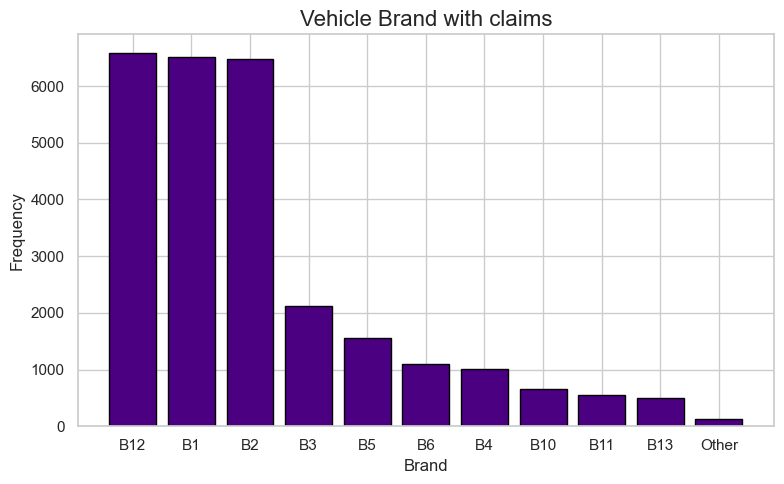

In [17]:
#Car brands with claim over 0
Brand = Claimed["VehBrand"].value_counts()
x3 = Brand.index
y3 = Brand.values

plt.figure(figsize=(8, 5))
plt.bar(x3,y3,color='Indigo', edgecolor='black')
plt.title('Vehicle Brand with claims', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


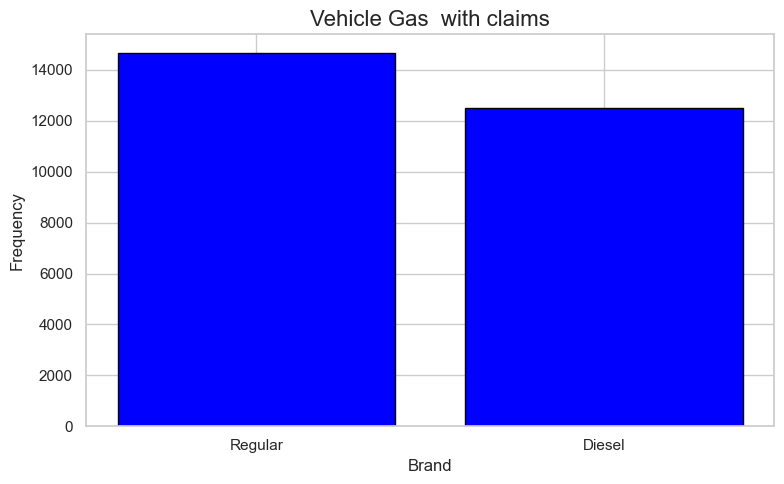

In [18]:
#Vehicle brands with Claims
VehGas = Claimed["VehGas"].value_counts()
x4 = VehGas.index
y4 = VehGas.values

plt.figure(figsize=(8, 5))
plt.bar(x4,y4,color='blue', edgecolor='black')
plt.title('Vehicle Gas  with claims', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
#correlation
Corr = df[['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'Density', ]]

corr_matrix = Corr.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Selected Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KeyError: "['IDpol'] not in index"